In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("processed/cleaned_global_edu_policy.csv")

metadata_cols = ["iso3", "country", "region", "wb_econ"]
df_meta = df[metadata_cols]

features = [
    "gdp_pc_ppp", "urban_pct", "youth_dependency_ratio", "lfp_gender_gap",
    "finbar_prim", "compend_prim", "disc_sex_prim", "incl_edu"
]
X = df[features]

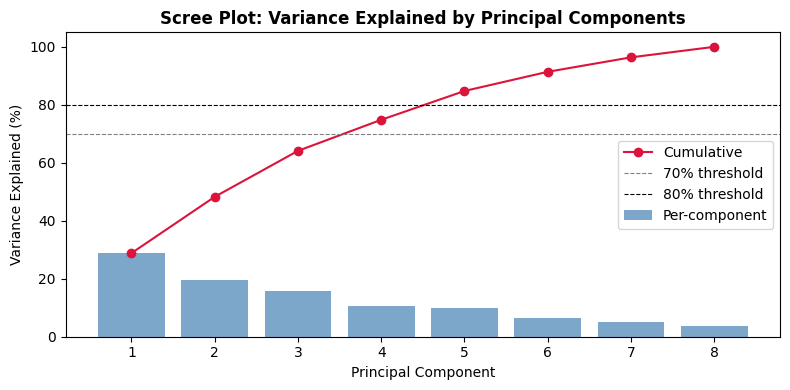


Cumulative variance explained:
  PC1: 28.8%
  PC2: 48.3%
  PC3: 64.1%
  PC4: 74.8%
  PC5: 84.8%
  PC6: 91.4%
  PC7: 96.4%
  PC8: 100.0%


In [24]:
# Run PCA on all features to see how much variance each component captures.
# This helps us decide how many components to keep before clustering.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumulative = np.cumsum(evr)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(range(1, len(evr) + 1), evr * 100, color="steelblue", alpha=0.7, label="Per-component")
ax1.plot(range(1, len(evr) + 1), cumulative * 100, color="crimson", marker="o", label="Cumulative")
ax1.axhline(70, color="grey", linestyle="--", linewidth=0.8, label="70% threshold")
ax1.axhline(80, color="black", linestyle="--", linewidth=0.8, label="80% threshold")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Variance Explained (%)")
ax1.set_xticks(range(1, len(evr) + 1))
ax1.set_title("Scree Plot: Variance Explained by Principal Components", fontweight="bold")
ax1.legend()
plt.tight_layout()
plt.savefig("processed/scree_plot.png", dpi=300)
plt.show()

print("\nCumulative variance explained:")
for i, c in enumerate(cumulative):
    print(f"  PC{i+1}: {c*100:.1f}%")

In [26]:
# Set up a pipeline to scale the data and reduce it to 4 principal components
N_COMPONENTS = 4

preprocessing_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=N_COMPONENTS, random_state=42))
])

X_pca = preprocessing_pipeline.fit_transform(X)
fitted_pca = preprocessing_pipeline.named_steps["pca"]

print("PCA Dimensionality Reduction")
for i, v in enumerate(fitted_pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v*100:.2f}%")
print(f"  Total: {fitted_pca.explained_variance_ratio_.sum()*100:.2f}%")

PCA Dimensionality Reduction
  PC1: 28.82%
  PC2: 19.43%
  PC3: 15.86%
  PC4: 10.71%
  Total: 74.82%


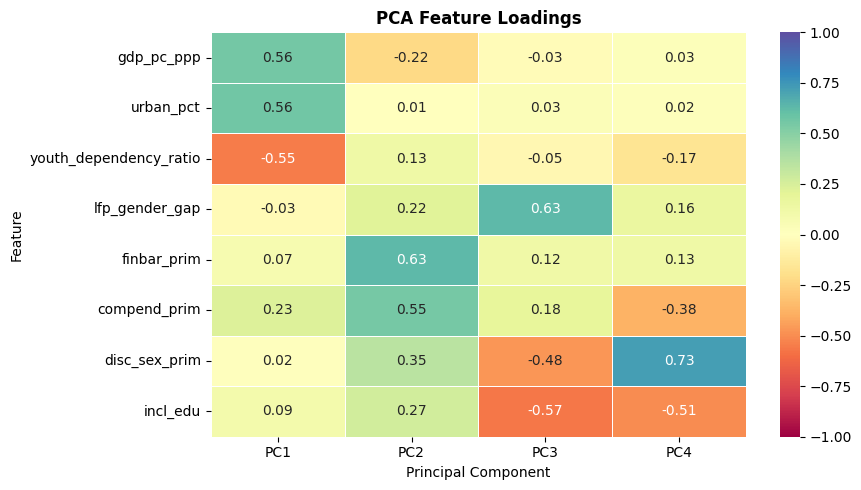

In [27]:
# Create a heatmap to see how much each feature contributes to the principal components
loadings = pd.DataFrame(
    fitted_pca.components_.T,
    columns=[f"PC{i+1}" for i in range(N_COMPONENTS)],
    index=X.columns
)

plt.figure(figsize=(9, 5))
sns.heatmap(
    loadings, annot=True, cmap="Spectral",
    vmin=-1, vmax=1, fmt=".2f", linewidths=0.5
)
plt.title("PCA Feature Loadings", fontweight="bold")
plt.ylabel("Feature")
plt.xlabel("Principal Component")
plt.tight_layout()
plt.savefig("processed/pca_loadings_heatmap.png", dpi=300)
plt.show()

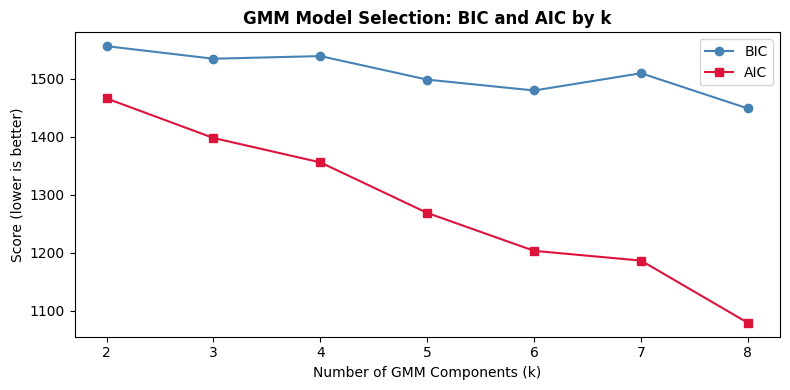

BIC scores: {2: np.float64(1555.9), 3: np.float64(1534.3), 4: np.float64(1538.8), 5: np.float64(1498.3), 6: np.float64(1479.5), 7: np.float64(1509.3), 8: np.float64(1448.5)}
AIC scores: {2: np.float64(1465.9), 3: np.float64(1397.6), 4: np.float64(1355.6), 5: np.float64(1268.4), 6: np.float64(1203.1), 7: np.float64(1186.3), 8: np.float64(1078.9)}


In [28]:
# GMM needs the number of clusters (k) defined upfront. 
# We use BIC and AIC to check different k values; a lower score or an elbow indicates a better fit.
# BIC is usually better here because it penalizes model complexity more strictly.
bic_scores = []
aic_scores = []
k_range = range(2, 9)

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                          random_state=42, n_init=10)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, bic_scores, marker="o", label="BIC", color="steelblue")
ax.plot(k_range, aic_scores, marker="s", label="AIC", color="crimson")
ax.set_xlabel("Number of GMM Components (k)")
ax.set_ylabel("Score (lower is better)")
ax.set_xticks(list(k_range))
ax.set_title("GMM Model Selection: BIC and AIC by k", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("processed/gmm_bic_aic.png", dpi=300)
plt.show()

print("BIC scores:", {k: round(b, 1) for k, b in zip(k_range, bic_scores)})
print("AIC scores:", {k: round(a, 1) for k, a in zip(k_range, aic_scores)})

In [32]:
# BIC hits its first local minimum at k=3 before flattening out.
# While the global minimum is at k=6, splitting 165 countries into 6 groups 
# makes the clusters too small to profile reliably. 
# Choosing k=3 balances statistical fit with practical interpretability.
K = 3

gmm = GaussianMixture(n_components=K, covariance_type="full",
                      random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(X_pca)

df_results = df_meta.copy()
df_results["PC1"] = X_pca[:, 0]
df_results["PC2"] = X_pca[:, 1]
df_results["PC3"] = X_pca[:, 2]
df_results["PC4"] = X_pca[:, 3]
df_results["gmm_cluster"] = gmm_labels.astype(str)

print("GMM Cluster Distribution")
print(df_results["gmm_cluster"].value_counts().sort_index())
print(f"\nConverged: {gmm.converged_}  |  Iterations: {gmm.n_iter_}")

GMM Cluster Distribution
gmm_cluster
0      7
1     53
2    105
Name: count, dtype: int64

Converged: True  |  Iterations: 21


In [33]:
# Check how cluster sizes distribute across different values of k to watch for tiny groups
for k in [2, 3, 4, 5]:
    gmm_test = GaussianMixture(n_components=k, covariance_type="full",
                               random_state=42, n_init=10)
    labels_test = gmm_test.fit_predict(X_pca)
    counts = pd.Series(labels_test).value_counts().sort_index().values
    print(f"k={k}: {sorted(counts, reverse=True)}")

k=2: [np.int64(105), np.int64(60)]
k=3: [np.int64(105), np.int64(53), np.int64(7)]
k=4: [np.int64(74), np.int64(50), np.int64(34), np.int64(7)]
k=5: [np.int64(63), np.int64(45), np.int64(40), np.int64(10), np.int64(7)]


In [34]:
# This 7-country group shows up consistently for every k from 3 and up.
# We isolate them to see if they form a meaningful subgroup or if they 
# are just extreme outliers that need separate handling.

gmm_k3 = GaussianMixture(n_components=3, covariance_type="full",
                          random_state=42, n_init=10)
labels_k3 = gmm_k3.fit_predict(X_pca)

df_inspect = df_meta.copy()
df_inspect["gmm_cluster"] = labels_k3
df_inspect["PC1"] = X_pca[:, 0]
df_inspect["PC2"] = X_pca[:, 1]
df_inspect["PC3"] = X_pca[:, 2]
df_inspect["PC4"] = X_pca[:, 3]

# Merge original feature values for profiling
df_inspect = df_inspect.join(X)

outlier_cluster = df_inspect["gmm_cluster"].value_counts().idxmin()
outliers = df_inspect[df_inspect["gmm_cluster"] == outlier_cluster]

print(f"Outlier cluster label: {outlier_cluster}")
print(f"\nCountries:\n")
print(outliers[["country", "region", "wb_econ"]].to_string(index=False))
print(f"\nFeature profile:\n")
print(outliers[["PC1","PC2","PC3","PC4"] + features].round(2).T)

Outlier cluster label: 0

Countries:

         country              region  wb_econ
          Bhutan          South Asia      2.0
        Botswana  Sub-Saharan Africa      2.0
         Burundi  Sub-Saharan Africa      1.0
Papua New Guinea East Asia & Pacific      2.0
 Solomon Islands East Asia & Pacific      2.0
    South Africa  Sub-Saharan Africa      2.0
         Vanuatu East Asia & Pacific      2.0

Feature profile:

                             17        20       25       114      133  \
PC1                        -1.89     -1.46    -3.23    -3.39    -3.61   
PC2                        -4.19     -2.95    -1.97    -4.98    -7.51   
PC3                        -1.04     -1.27    -1.50    -0.89    -1.35   
PC4                         2.81      2.83     0.60     0.82     0.22   
gdp_pc_ppp              15063.81  19976.83  1104.78  4419.62  2496.23   
urban_pct                  40.94     66.59    22.32    14.74    29.35   
youth_dependency_ratio      0.31      0.51     0.89     0.54    

In [35]:
# While k=3 is the first BIC minimum, it isolates a tiny 7-country cluster.
# Because this group persists from k=3 through k=5, they are genuine outliers 
# in the PCA space rather than a clustering artifact.
# These countries share a distinct gap in education legislation despite having 
# different income levels, forming a clear "legislative gap" archetype.
# Moving to k=4 keeps this distinct group while splitting the rest into three well-sized clusters.
K = 4

gmm = GaussianMixture(n_components=K, covariance_type="full",
                      random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(X_pca)

df_results = df_meta.copy()
df_results["PC1"] = X_pca[:, 0]
df_results["PC2"] = X_pca[:, 1]
df_results["PC3"] = X_pca[:, 2]
df_results["PC4"] = X_pca[:, 3]
df_results["gmm_cluster"] = gmm_labels.astype(str)

print("GMM Cluster Distribution (k=4)")
print(df_results["gmm_cluster"].value_counts().sort_index())
print(f"\nConverged: {gmm.converged_}  |  Iterations: {gmm.n_iter_}")

GMM Cluster Distribution (k=4)
gmm_cluster
0    34
1    50
2    74
3     7
Name: count, dtype: int64

Converged: True  |  Iterations: 13


In [36]:
# GMM gives us the probability of a country belonging to each cluster. 
# A high average maximum probability means the clusters are well-separated, 
# while lower scores mean there is a lot of overlap in the PCA space.
probs = gmm.predict_proba(X_pca)
df_results["max_prob"] = probs.max(axis=1)

print("Mean assignment confidence per cluster:")
print(df_results.groupby("gmm_cluster")["max_prob"].mean().round(3))
print(f"\nOverall mean confidence: {df_results['max_prob'].mean():.3f}")
print(f"Countries with max_prob < 0.80: {(df_results['max_prob'] < 0.80).sum()}")

Mean assignment confidence per cluster:
gmm_cluster
0    0.948
1    1.000
2    0.980
3    1.000
Name: max_prob, dtype: float64

Overall mean confidence: 0.980
Countries with max_prob < 0.80: 6


In [38]:
# Map the cluster labels back to our original, unscaled data to calculate the averages. 
# This gives us a clear profile for each group and helps us name the archetypes.
df_analysis = X.copy()
df_analysis["gmm_cluster"] = gmm_labels

cluster_profiles = df_analysis.groupby("gmm_cluster").mean()

print("Mean Feature Profiles by GMM Cluster")
print(cluster_profiles.round(2).T)

Mean Feature Profiles by GMM Cluster
gmm_cluster                    0         1         2        3
gdp_pc_ppp              59192.12  30493.98  14017.52  8751.85
urban_pct                  76.18     60.10     55.59    37.09
youth_dependency_ratio      0.25      0.44      0.52     0.57
lfp_gender_gap             11.74     24.26     20.53     8.02
finbar_prim                 2.91      2.80      3.00     1.57
compend_prim                3.00      3.00      3.00     0.71
disc_sex_prim               3.00      1.24      3.00     2.43
incl_edu                    0.85      0.86      1.53     0.43


In [42]:
# Print the full list of countries in each cluster.
# This lets us quickly scan the country names alongside their assigned cluster.
for cluster_id in sorted(df_results["gmm_cluster"].unique()):
    print(f"Cluster {cluster_id} Countries:")
    
    cluster_countries = df_results[df_results["gmm_cluster"] == cluster_id]["country"].tolist()
    print(", ".join(sorted(cluster_countries)))
    print()

Cluster 0 Countries:
Australia, Belarus, Belgium, China, Croatia, Czech Republic, Denmark, Estonia, Finland, France, Germany, Hungary, Iceland, Ireland, Israel, Italy, Japan, Latvia, Lithuania, Luxembourg, Malta, New Zealand, Poland, Republic of Korea, Romania, Russian Federation, Slovakia, Slovenia, Spain, Sweden, The Netherlands, Trinidad and Tobago, United Kingdom, United States of America

Cluster 1 Countries:
Afghanistan, Austria, Bahamas, Bahrain, Bangladesh, Barbados, Belize, Brunei, Cabo Verde, Cambodia, Cameroon, Canada, Cyprus, Equatorial Guinea, Fiji, Ghana, Greece, Guyana, Haiti, Iran, Iraq, Jamaica, Jordan, Lebanon, Liberia, Madagascar, Malaysia, Myanmar, Norway, Oman, Pakistan, Portugal, Qatar, Rwanda, Samoa, Sao Tome and Principe, Saudi Arabia, Singapore, Somalia, St. Lucia, St. Vincent and the Grenadines, Sudan, Suriname, Switzerland, Syria, Tanzania, Thailand, Timor-Leste, Tonga, United Arab Emirates

Cluster 2 Countries:
Albania, Algeria, Angola, Argentina, Armenia, A

In [44]:
# Map clean, descriptive names using string keys to match the cluster column data type.
# We focus entirely on the clear income levels and standout policy traits.
archetype_labels = {
    "0": "High-Income / Complete Legal Protections",
    "1": "Middle-to-High Income / High Gender Equity Gaps",
    "2": "Lower-Middle Income / Progressive Education Laws",
    "3": "Low-Income / Severe Legislative Gaps"
}

df_results["archetype"] = df_results["gmm_cluster"].map(archetype_labels)
df_results[["country", "gmm_cluster", "archetype"]].head(10)

,country,gmm_cluster,archetype
0,Afghanistan,1,Middle-to-High Income / High Gender Equity Gaps
1,Albania,2,Lower-Middle Income / Progressive Education Laws
2,Algeria,2,Lower-Middle Income / Progressive Education Laws
3,Angola,2,Lower-Middle Income / Progressive Education Laws
4,Argentina,2,Lower-Middle Income / Progressive Education Laws
5,Armenia,2,Lower-Middle Income / Progressive Education Laws
6,Australia,0,High-Income / Complete Legal Protections
7,Austria,1,Middle-to-High Income / High Gender Equity Gaps
8,Azerbaijan,2,Lower-Middle Income / Progressive Education Laws
9,Bahamas,1,Middle-to-High Income / High Gender Equity Gaps


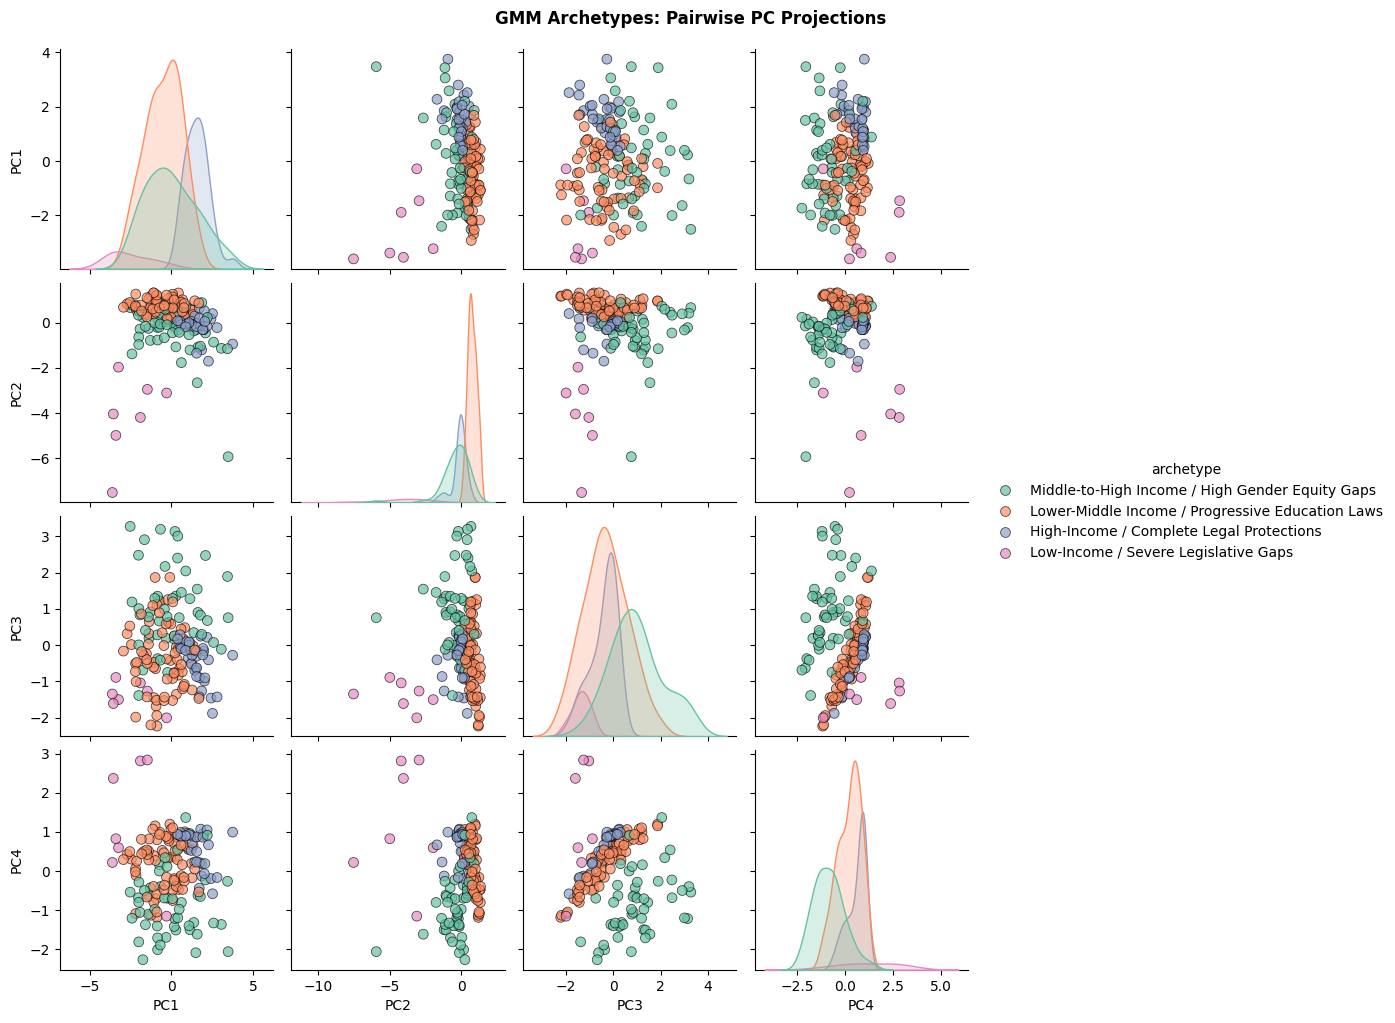

In [45]:
g = sns.pairplot(
    df_results, vars=["PC1", "PC2", "PC3", "PC4"],
    hue="archetype", palette="Set2",
    diag_kind="kde",
    plot_kws={"alpha": 0.7, "edgecolor": "k", "s": 50}
)
g.fig.suptitle("GMM Archetypes: Pairwise PC Projections", y=1.02, fontweight="bold")
plt.savefig("processed/gmm_pairwise.png", dpi=300, bbox_inches="tight")
plt.show()

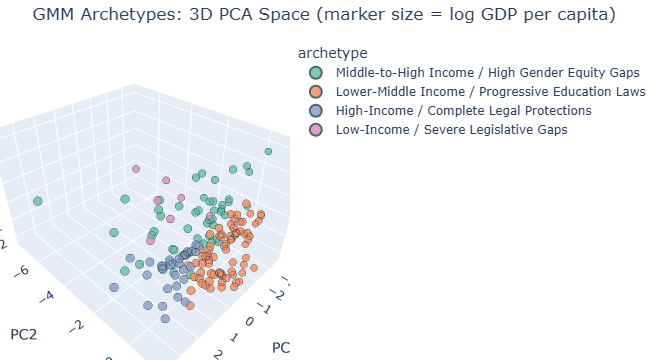

In [47]:
import plotly.express as px

df_results["gdp_marker_size"] = np.log1p(df["gdp_pc_ppp"])

fig = px.scatter_3d(
    df_results,
    x="PC1", y="PC2", z="PC3",
    color="archetype",
    size="gdp_marker_size", size_max=14,
    hover_name="country",
    hover_data=["region", "wb_econ", "max_prob"],
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="GMM Archetypes: 3D PCA Space (marker size = log GDP per capita)",
)
fig.update_traces(marker=dict(opacity=0.85, line=dict(width=1, color="DarkSlateGrey")))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

In [48]:
df_results.to_csv("processed/gmm_clusters.csv", index=False)
print("Saved: processed/gmm_clusters.csv")
print(f"Shape: {df_results.shape}")
print(f"Columns: {df_results.columns.tolist()}")

Saved: processed/gmm_clusters.csv
Shape: (165, 12)
Columns: ['iso3', 'country', 'region', 'wb_econ', 'PC1', 'PC2', 'PC3', 'PC4', 'gmm_cluster', 'max_prob', 'archetype', 'gdp_marker_size']


In [49]:
brics = ["Brazil", "Russian Federation", "India", "China", "South Africa"]
g7    = ["Canada", "France", "Germany", "Italy", "Japan", "United Kingdom",
         "United States of America"]

df_lookup = df_results[["country", "region", "wb_econ", "gmm_cluster", "archetype", "max_prob"]].copy()

for group_name, members in [("BRICS", brics), ("G7", g7)]:
    print(f"\n--- {group_name} ---")
    result = df_lookup[df_lookup["country"].isin(members)].sort_values("gmm_cluster")
    missing = [c for c in members if c not in df_lookup["country"].values]
    print(result.to_string(index=False))
    if missing:
        print(f"  Not in dataset: {missing}")
    print("-" * 75)


--- BRICS ---
           country                region  wb_econ gmm_cluster                                        archetype  max_prob
             China   East Asia & Pacific      2.0           0         High-Income / Complete Legal Protections  0.526434
Russian Federation Europe & Central Asia      4.0           0         High-Income / Complete Legal Protections  0.984355
            Brazil              Americas      2.0           2 Lower-Middle Income / Progressive Education Laws  0.991135
             India            South Asia      2.0           2 Lower-Middle Income / Progressive Education Laws  0.994432
      South Africa    Sub-Saharan Africa      2.0           3             Low-Income / Severe Legislative Gaps  0.998941
---------------------------------------------------------------------------

--- G7 ---
                 country                region  wb_econ gmm_cluster                                       archetype  max_prob
                  France Europe & Central Asi